# Calculate Expected Events
Determine the likelihood of observing microlensing events towards the LMC

## Generic Imports

In [3]:
import numpy as np
from scipy.integrate import quad

## Calculate Optical Depth

In [4]:
# Constants
G = 4.30091e-6  # kpc M_sun^-1 (km/s)^2
c = 3.0e5       # km/s
# NFW profile parameters for Milky Way
# Reference values (arXiv:2211.00666)
rho_s = 4.88e6  # M_sun / kpc^3
r_s = 21.5      # kpc
R_sun = 8.0     # kpc

# Define NFW profile
def rho_nfw(r):
    return rho_s / ((r / r_s) * (1 + r / r_s)**2)

# Observer at R_sun, viewing toward LMC. 
# Simplified: assume line of sight (l, b) is constant toward LMC. 
# For LMC, typically l = 280 deg, b = -33 deg.
# Distance to LMC D_s = 50 kpc
D_s = 50.0 
l = np.radians(280)
b = np.radians(-33)

def dist_from_center(d_l):
    # Coordinate system: Observer at (R_sun, 0, 0)
    # Lens at distance d_l from observer along line of sight toward (l, b)
    # x = R_sun - d_l * cos(b) * cos(l)
    # y = d_l * cos(b) * sin(l)
    # z = d_l * sin(b)
    x = R_sun - d_l * np.cos(b) * np.cos(l)
    y = d_l * np.cos(b) * np.sin(l)
    z = d_l * np.sin(b)
    return np.sqrt(x**2 + y**2 + z**2)

# Optical Depth integral: tau = (4 * pi * G) / c^2 * integral(rho(d_l) * d_l * (D_s - d_l) / D_s) dd_l
def integrand(d_l):
    r = dist_from_center(d_l)
    return rho_nfw(r) * d_l * (D_s - d_l) / D_s

tau, error = quad(integrand, 0, D_s)
tau = (4 * np.pi * G / c**2) * tau

print(f"{tau=}")

tau=3.764290640746729e-07


## Calculate Einstein Radius

In [ ]:
# Constants
G = 6.67430e-11  # m^3 kg^-1 s^-2
c = 2.99792e8    # m/s
M_sun = 1.989e30 # kg
kpc_to_m = 3.086e19 

def einstein_rad(m, d_l_kpc, d_s_kpc):
    # Convert distances to meters
    d_l = d_l_kpc * kpc_to_m
    d_s = d_s_kpc * kpc_to_m
    d_ls = d_s - d_l # Assuming flat space approximation
    
    # Formula: sqrt( (4 * G * M / c^2) * (d_ls / (d_l * d_s)) )
    return np.sqrt((4 * G * m / c**2) * (d_ls / (d_l * d_s)))

einstein_radius = einstein_rad(10**4 * M_sun, 25.0, 50.0)
print(f"Einstein radius (radians): {einstein_radius}")

einstein_radius_m = einstein_radius * 25.0 * kpc_to_m
print(f"Einstein radius (meters): {einstein_radius_m:e}")

Einstein radius (radians): 1.9568036355874521e-07
Einstein radius (meters): 1.509674e+14


## Calculate Crossing Time

In [13]:
v_perp = 2e5  # Example: 200 km/s (converted to m/s)
seconds_in_year = 365.25 * 24 * 3600

def calculate_crossing_time(r_e, v_t):
    """
    Calculates Einstein crossing time in seconds and years.
    r_e: Einstein radius in meters
    v_t: Transverse velocity in m/s
    """
    t_e_seconds = r_e / v_t
    t_e_years = t_e_seconds / seconds_in_year
    return t_e_seconds, t_e_years

t_e_sec, t_e_yr = calculate_crossing_time(einstein_radius_m, v_perp)

print(f"Einstein crossing time: {t_e_sec:.2e} seconds")
print(f"Einstein crossing time: {t_e_yr:.2f} years")

Einstein crossing time: 7.55e+08 seconds
Einstein crossing time: 23.92 years


## Calculate Event Rate 

In [15]:
def calculate_event_rate(tau, t_e):
    """
    Calculates the microlensing event rate (Gamma).
    tau: Optical depth
    t_e: Einstein crossing time in years
    """
    # Formula: Gamma = 2 * tau / (pi * t_E)
    gamma = (2 * tau) / (np.pi * t_e)
    return gamma

gamma_result = calculate_event_rate(tau, t_e_yr)

print(f"Microlensing event rate (events/star/year): {gamma_result:e}")

Microlensing event rate (events/star/year): 1.001876e-08


## Plots

<>:19: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:19: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_168121/1598449505.py:19: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('Black Hole Mass ($M_{\odot}$)')


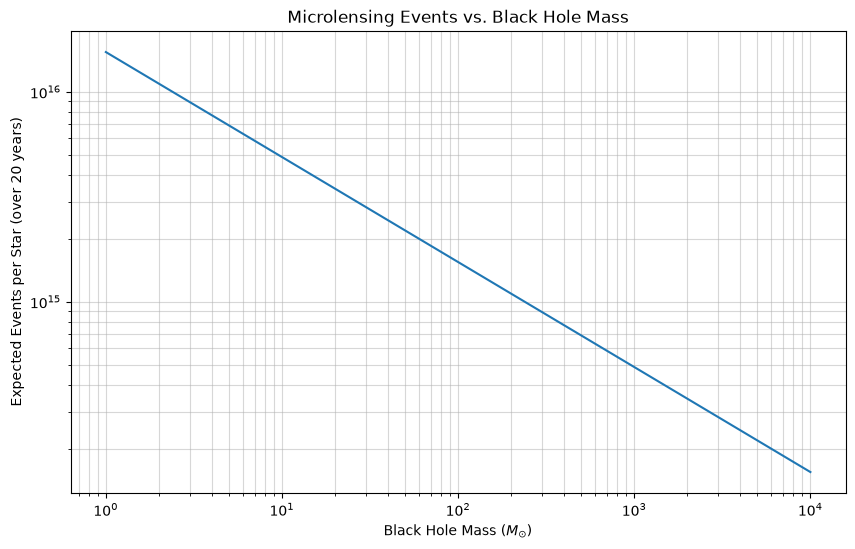

In [ ]:
import matplotlib.pyplot as plt

masses = np.linspace(1, 10000, 50) # 10^1 to 10^4 M_sun

# Calculate events for each mass
events_over_20_years = []
for m in masses:
    r_e = einstein_rad(m * M_sun, 25.0, 50.0)
    t_e_sec, t_e_yr = calculate_crossing_time(r_e, v_perp)
    gamma = calculate_event_rate(tau, t_e_yr)
    events = gamma * 20 # 20 year monitoring
    events_over_20_years.append(events)

# Plot - unrealistic; we lack a proper efficiency function!
plt.figure(figsize=(10, 6))
plt.plot(masses, events_over_20_years)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Black Hole Mass ($M_{\odot}$)')
plt.ylabel('Expected Events per Star (over 20 years)')
plt.title('Microlensing Events vs. Black Hole Mass')
plt.grid(True, which="both", ls="-", alpha=0.5)